# Top 10 NYCHA TDSs by Total Energy Cost per Unit
This notebook creates a horizontal stacked bar chart showing the top 10 TDSs by total energy cost per unit, broken out by steam, gas, and electricity costs. Data is aggregated by TDS number to avoid duplicate developments.

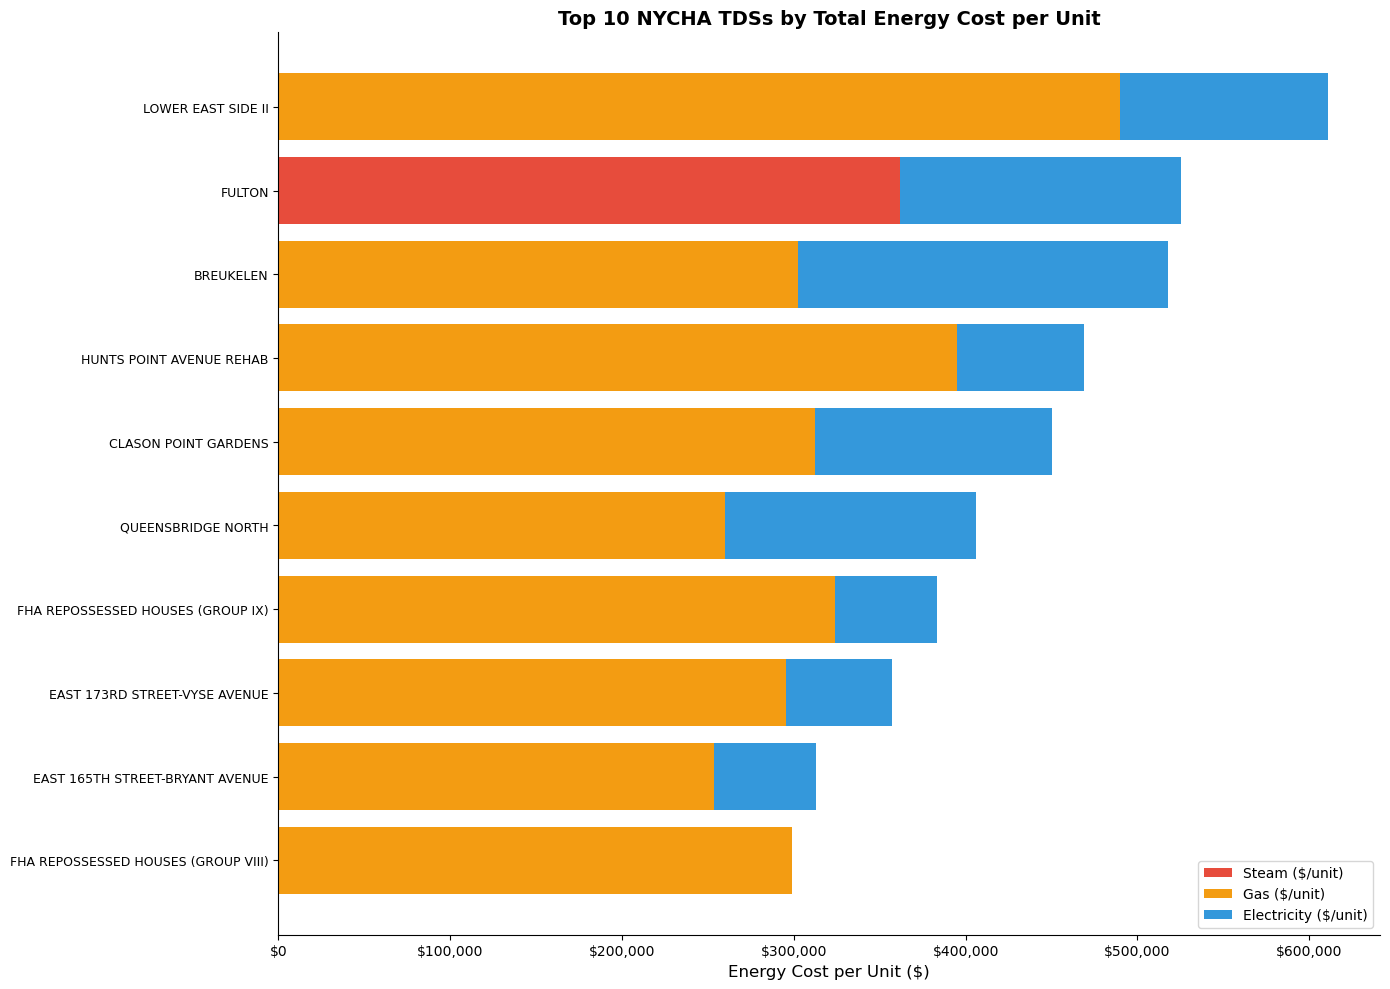

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

base = Path().resolve().parent
df = pd.read_csv(base / "cleaned_data/combined_utilities_2024.csv")

# Use unitsres, falling back to unitstotal when NaN
df['units'] = df['unitsres'].fillna(df['unitstotal'])

# Group by TDS — aggregate total costs then divide by total units
tds = df.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'total_units': g['units'].sum(),
        'total_steam_charges': g['steam_current_charges'].fillna(0).sum(),
        'total_gas_charges': g['gas_current_charges'].fillna(0).sum(),
        'total_elec_charges': g['electricity_current_charges'].fillna(0).sum(),
    }),
    include_groups=False,
).reset_index(drop=True)

# Recalculate per-unit costs at the TDS level
tds['steam_cost_per_unit'] = tds['total_steam_charges'] / tds['total_units']
tds['gas_cost_per_unit'] = tds['total_gas_charges'] / tds['total_units']
tds['elec_cost_per_unit'] = tds['total_elec_charges'] / tds['total_units']
tds['total_cost_per_unit'] = (
    tds['steam_cost_per_unit'] + tds['gas_cost_per_unit'] + tds['elec_cost_per_unit']
)

# Top 10 TDSs by total cost per unit
top10 = tds.nlargest(10, 'total_cost_per_unit').sort_values('total_cost_per_unit', ascending=True)

steam_vals = top10['steam_cost_per_unit'].fillna(0).values
gas_vals = top10['gas_cost_per_unit'].fillna(0).values
elec_vals = top10['elec_cost_per_unit'].fillna(0).values
labels = top10['development'].values

# Horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(labels))

ax.barh(y, steam_vals, label='Steam ($/unit)', color='#e74c3c')
ax.barh(y, gas_vals, left=steam_vals, label='Gas ($/unit)', color='#f39c12')
ax.barh(y, elec_vals, left=steam_vals + gas_vals, label='Electricity ($/unit)', color='#3498db')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Energy Cost per Unit ($)', fontsize=12)
ax.set_title('Top 10 NYCHA TDSs by Total Energy Cost per Unit', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()